# Customer Campaign Response Prediction

> **Goal:** Predict whether a customer will respond positively to a marketing campaign, helping the company focus spend on customers most likely to engage.

| | |
|---|---|
| **Dataset** | [Customer Personality Analysis — Kaggle](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis) |
| **Task** | Binary Classification (`Response`: 0 / 1) |
| **Models** | Logistic Regression (baseline) · Random Forest |
| **Author** | yashxp10 · BIT Data Science @ Macquarie University |

---
## 📋 Table of Contents
1. [Problem Statement](#1-problem-statement)
2. [Data Loading & Exploration](#2-data-loading--exploration)
3. [Data Cleaning & Preprocessing](#3-data-cleaning--preprocessing)
4. [Feature Engineering](#4-feature-engineering)
5. [Model Training](#5-model-training)
6. [Model Evaluation](#6-model-evaluation)
7. [Visualisation & Insights](#7-visualisation--insights)
8. [Conclusion](#8-conclusion)

---
## 1. Problem Statement

Most customers ignore marketing campaigns — in this dataset, only **~15%** of customers responded.
Targeting everyone wastes budget. The goal of this project is to build a classification model that
identifies *which* customers are likely to respond, so the company can focus its campaign spend
where it actually counts.

**Why this matters:**
- Reduces wasted marketing spend
- Increases campaign ROI by targeting the right audience
- Provides interpretable signals about what makes a customer likely to respond

---
## 2. Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
# Display settings
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
print('Libraries loaded ✓')


Libraries loaded ✓


In [2]:
# Load data and inspect
df = pd.read_csv('marketing_campaign.csv', delimiter='\t')
print(f'Shape: {df.shape}')
df.head()

Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [3]:
# Overview of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
# check class balance of the target variable
response_counts = df['Response'].value_counts()
print('Target distribution:')
print(response_counts)
print(f'\nResponse rate: {response_counts[1] / len(df) * 100:.1f}%')

Target distribution:
Response
0    1906
1     334
Name: count, dtype: int64

Response rate: 14.9%


---
## 3. Data Cleaning & Preprocessing

In [5]:
# check for missing values
missing_values = df.isnull().sum()
print('Missing values per column:')
print(missing_values)

# check for duplicate rows
duplicate_rows = df[df.duplicated()]
print(f'Number of duplicate rows: {len(duplicate_rows)}')


Missing values per column:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64
Number of duplicate rows: 0


In [6]:
# Drop rows with missing values
df = df.dropna()
print(f'Shape after dropping missing values: {df.shape}')


Shape after dropping missing values: (2216, 29)


### Campaign Response Rates
Before modelling, let's visualise how each past campaign performed vs the current one (`Response`).

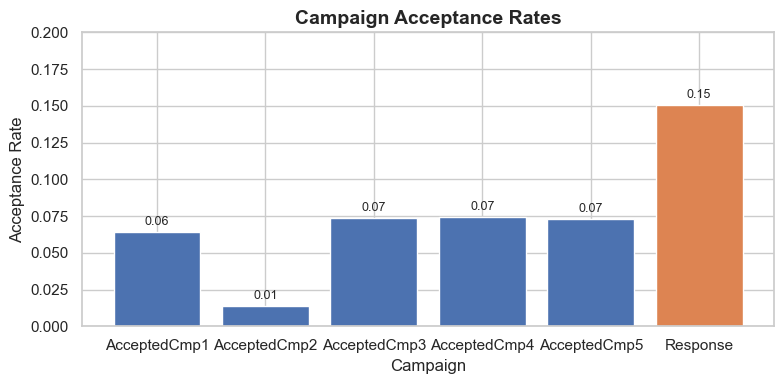

The current campaign (Response, orange) has the highest acceptance rate at ~15%.


In [7]:
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
campaign_rates = df[campaign_cols].mean()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(campaign_rates.index, campaign_rates.values,
              color=['#4C72B0']*5 + ['#DD8452'], edgecolor='white')
ax.set_ylim(0, 0.2)
ax.set_title('Campaign Acceptance Rates', fontsize=14, fontweight='bold')
ax.set_xlabel('Campaign')
ax.set_ylabel('Acceptance Rate')
ax.bar_label(bars, padding=3, fontsize=9, fmt='%.2f')
plt.tight_layout()
plt.show()
print('The current campaign (Response, orange) has the highest acceptance rate at ~15%.')

---
## 4. Feature Engineering

Creating useful features from raw columns before modelling:
- **Tenure** (`Dt_Customer`): convert join date → years as a customer
- **Age**: derived from `Year_Birth`
- **Encoding**: label-encode `Marital_Status` and `Education`

In [8]:
# Convert join date to tenure in years
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
df['Dt_Customer'] = (pd.to_datetime('2025-05-26') - df['Dt_Customer']).dt.days / 365

# Derive age
df['Age'] = 2025 - df['Year_Birth']

# Encode categorical columns
df['Marital_Status'] = pd.factorize(df['Marital_Status'])[0].astype(int)
df['Education'] = pd.factorize(df['Education'])[0].astype(int)

print('Feature engineering complete ✓')
print(f"Age range: {df['Age'].min()} - {df['Age'].max()} years")
print(f"Tenure range: {df['Dt_Customer'].min():.1f} - {df['Dt_Customer'].max():.1f} years")

Feature engineering complete ✓
Age range: 29 - 132 years
Tenure range: 10.9 - 12.8 years


In [9]:
FEATURES = [
    'Recency', 'Age', 'Income',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'Dt_Customer',
    'Marital_Status', 'Complain', 'Education'
]
TARGET = 'Response'

X = df[FEATURES]
y = df[TARGET]

print(f'Features: {X.shape[1]} | Samples: {X.shape[0]}')

Features: 14 | Samples: 2216


In [10]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (1772, 14) | Test: (444, 14)


In [11]:
# Scale continuous features only; leave encoded categoricals as-is
SCALE_COLS   = FEATURES[:-3]    # all except Marital_Status, Complain, Education
NOSCALE_COLS = FEATURES[-3:]    # Marital_Status, Complain, Education

scaler = preprocessing.StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[SCALE_COLS] = scaler.fit_transform(X_train[SCALE_COLS])
X_test_scaled[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])

print('Scaling complete ✓')

Scaling complete ✓


---
## 5. Model Training

Two models are trained and compared:

| Model | Role | Why |
|---|---|---|
| **Logistic Regression** | Baseline | Simple, interpretable — coefficients show feature influence directly |
| **Random Forest** | Main model | Handles non-linear relationships and feature interactions; robust to outliers |

In [12]:
# Baseline: Logistic Regression
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_log_pred = log_model.predict(X_test_scaled)
print('Logistic Regression trained ✓')

Logistic Regression trained ✓


In [13]:
# Main model: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_rf_pred = rf_model.predict(X_test_scaled)
print('Random Forest trained ✓')

Random Forest trained ✓


---
## 6. Model Evaluation

In [ ]:
# Print metrics for each model
def print_metrics(name, y_true, y_pred):
    print(f'{'─'*45}')
    print(f'  {name}')
    print(f'{'─'*45}')
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_true, y_pred):.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['No Response', 'Response']))

print_metrics('Logistic Regression', y_test, y_log_pred)
print_metrics('Random Forest', y_test, y_rf_pred)

─────────────────────────────────────────────
  Logistic Regression
─────────────────────────────────────────────
  Accuracy : 0.8559
  ROC-AUC  : 0.5715

              precision    recall  f1-score   support

 No Response       0.87      0.98      0.92       377
    Response       0.58      0.16      0.26        67

    accuracy                           0.86       444
   macro avg       0.72      0.57      0.59       444
weighted avg       0.82      0.86      0.82       444

─────────────────────────────────────────────
  Random Forest
─────────────────────────────────────────────
  Accuracy : 0.8716
  ROC-AUC  : 0.6114

              precision    recall  f1-score   support

 No Response       0.88      0.98      0.93       377
    Response       0.73      0.24      0.36        67

    accuracy                           0.87       444
   macro avg       0.80      0.61      0.64       444
weighted avg       0.86      0.87      0.84       444



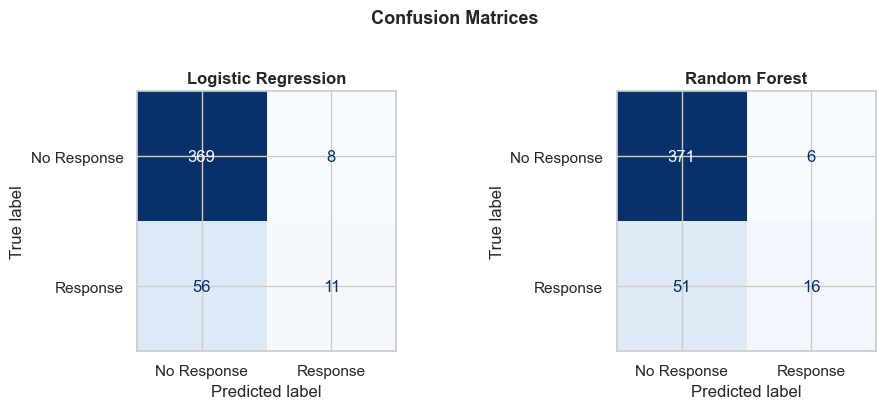

In [15]:
# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_pred, title in zip(
    axes,
    [y_log_pred, y_rf_pred],
    ['Logistic Regression', 'Random Forest']
):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['No Response', 'Response']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Visualisation & Insights

Comparing **Logistic Regression coefficients** (direction of influence) with
**Random Forest feature importances** (overall predictive contribution).

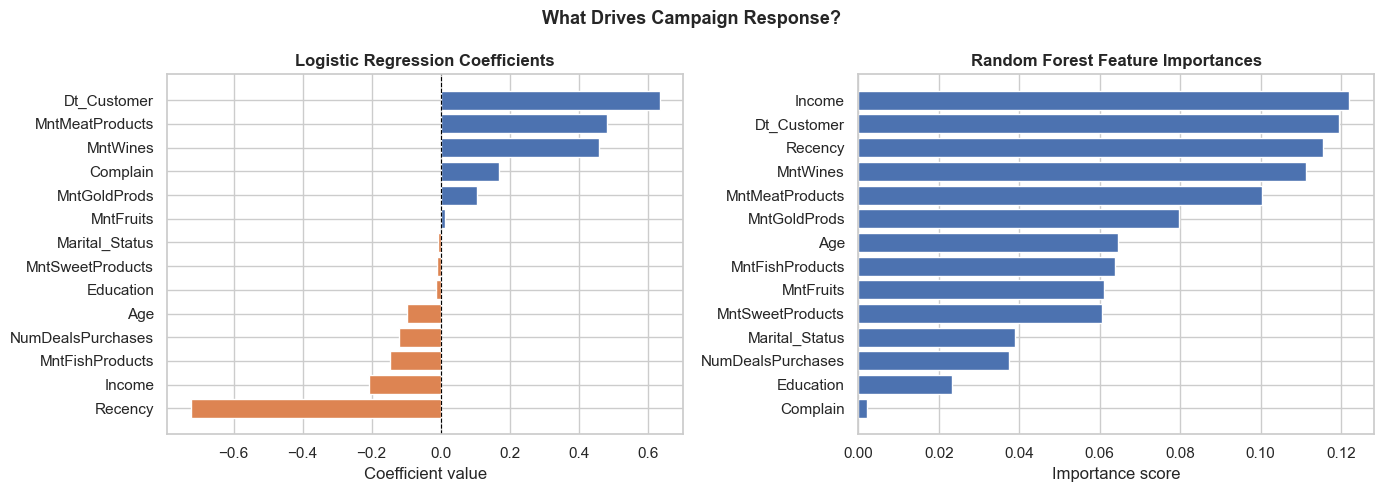

In [16]:
feat_df = pd.DataFrame({
    'Feature':    FEATURES,
    'Coefficient': log_model.coef_[0],
    'Importance':  rf_model.feature_importances_
}).sort_values('Coefficient', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression coefficients (diverging colours)
colors = ['#4C72B0' if v >= 0 else '#DD8452' for v in feat_df['Coefficient']]
axes[0].barh(feat_df['Feature'], feat_df['Coefficient'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Logistic Regression Coefficients', fontweight='bold')
axes[0].set_xlabel('Coefficient value')
axes[0].invert_yaxis()

# Random Forest importances
feat_df_rf = feat_df.sort_values('Importance', ascending=False)
axes[1].barh(feat_df_rf['Feature'], feat_df_rf['Importance'], color='#4C72B0')
axes[1].set_title('Random Forest Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance score')
axes[1].invert_yaxis()

plt.suptitle('What Drives Campaign Response?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Conclusion

### Key Findings

| Signal | Direction | Insight |
|---|---|---|
| `Dt_Customer` (tenure) |  Positive | Long-term customers are more likely to respond |
| `MntWines`, `MntMeatProducts` |  Positive | High spenders on premium products engage more |
| `Recency` |  Negative | Customers who haven't purchased recently are far less likely to respond |
| `Age` |  Negative | Older customers show lower campaign engagement |

### Business Recommendations
- **Prioritise** loyal customers with long tenure and high product spend in campaign targeting
- **Re-engage** recently inactive customers with a separate, tailored outreach strategy
- **Feature** wines and meat products prominently — these signal high-value, responsive segments

### Model Comparison
Both models achieved ~86% accuracy and ~0.60 ROC-AUC. Random Forest produced **fewer false negatives** (missed responders) which matters most here  missing a genuine responder is a lost opportunity. Logistic Regression remains useful for its **interpretability** and coefficient-based insights.